# Hiërarchisch mixed model van residentieel slimme-meterverbruik met PROC HPLMIXED

## Samenvatting

Een nutsbedrijf analyseert maandelijkse residentiële slimme-meterstanden voor huishoudens die genest zijn binnen distributie-onderstations. `PROC HPLMIXED` past een lineair mixed model toe dat het maandelijkse verbruik (kWh) relateert aan stookgraaddagen en tariefplan als vaste effecten, terwijl willekeurige intercepten voor onderstations en huishoudens de natuurlijke hiërarchie van het net opvangen. Op dit panel van 100 metingen herleidt het model een weerhelling van **8,12 kWh per stookgraaddag** en een reductie van **11,9 kWh** voor huishoudens met een piek-/dalplan, en wijst het het grootste deel van de onverklaarde variatie toe aan blijvende verschillen tussen **huishoudens** (variantiecomponent **105,0**) in plaats van tussen onderstations (**1,3**) — het signaal op huishoudenniveau waarop een nutsbedrijf zich richt met efficiëntieprogramma's. De fit levert ook per-meting voorspellingen en residuen op voor belastingsvoorspellingsdiagnostiek.

## Gegevensbronnen

**Synthetische dataset: `meter`** — inline gegenereerd met `call streaminit(20260531)` en `rand()`. Het volledige panel bestaat uit 5 onderstations x 4 huishoudens x 5 maanden = **100 metingen**, wat precies de analysesample is (er worden geen rijen afgekapt).

| Variabele | Type | Beschrijving |
|----------|------|-------------|
| `hh_id` | num | Huishouden-identificatie (1–20), genest binnen onderstation |
| `sub` | num | Distributie-onderstation-identificatie (1–5) |
| `plan` | char | Tariefplan: `FLAT` (vast tarief) of `TOU` (piek-/dalplan) |
| `month` | num | Kalendermaandindex (1–5) |
| `hdd` | num | Maandelijkse stookgraaddagen (weerdrijver, seizoensgebonden) |
| `kwh` | num | Maandelijks elektriciteitsverbruik van het huishouden (respons) |

De simulatie stapelt een vaste weerhelling en tariefoffset op willekeurige onderstationseffecten, willekeurige huishoudeffecten en een AR-achtige maand-op-maand verstoring, zodat zowel de vaste als de willekeurige structuur door het model kunnen worden teruggevonden.

# Modelleren van residentiële energievraag met PROC HPLMIXED

Nutsbedrijven moeten begrijpen *waarom* het elektriciteitsverbruik van huishoudens varieert: hoeveel wordt gedreven door weer en tariefontwerp (effecten die gedeeld worden over het hele verzorgingsgebied) versus blijvende verschillen tussen buurten en individuele woningen. Slimme-metergegevens zijn van nature **hiërarchisch** — maandelijkse metingen zijn genest binnen huishoudens, en huishoudens zijn genest binnen distributie-onderstations.

Een lineair **mixed model** is het juiste instrument: het schat *vaste effecten* (weer, tariefplan) die voor alle klanten gelden, terwijl onderstation en huishouden worden behandeld als *willekeurige effecten*, zodat het model kracht ontleent aan het hele net in plaats van voor elke meter een apart intercept te schatten. `PROC HPLMIXED` is het high-performance lid van de MIXED-familie, gebouwd voor de grote panels die slimme-meterprogramma's opleveren; hier demonstreren we het op een compact panel van 100 metingen.

Dit notebook simuleert een kort venster van metingen, past het model toe en onderzoekt de variantieontbinding en de residuele fit.

## Stap 1 — Simuleer een panel van slimme-metermetingen

We genereren een gebalanceerd panel van 5 onderstations, elk met 4 huishoudens, waargenomen over 5 maanden (100 metingen). Het datagenererende proces weerspiegelt het model dat we gaan toepassen:

- een **onderstationseffect** (`sub_eff`) gedeeld door alle woningen op die voedingslijn,
- een **basislast van het huishouden** (`hh_eff`) die blijft bestaan over het hele venster,
- een vaste **weerhelling** op stookgraaddagen (`hdd`), die een seizoensgebonden cosinus volgt,
- een vaste **tariefplanoffset** (piek-/dalklanten verlagen het piekverbruik), en
- een kleine autoregressieve maand-op-maand verstoring.

`call streaminit` legt de seed vast voor reproduceerbaarheid; alle willekeur komt van `rand()`.

In [1]:
GEGEVENS meter;
   CALL streaminit(20260531);

   /* Blijvend willekeurig effect per onderstation */
   REEKS sub_eff{5};
   DOE s = 1 TOT 5;
      sub_eff{s} = 12 * rand("normal");
   EINDE;

   DOE sub = 1 TOT 5;
      DOE hh = 1 TOT 4;
         hh_id  = (sub - 1)*4 + hh;       /* uniek huishouden-ID 1..20 */
         hh_eff = 9 * rand("normal");      /* blijvende basislast van het huishouden */
         baseload = 380 + sub_eff{sub} + hh_eff;

         /* Wijs elk huishouden een tariefplan toe */
         ALS rand("uniform") < 0.5 DAN plan = "TOU ";
         ANDERS plan = "FLAT";

         prev = 0;
         DOE month = 1 TOT 5;
            /* Stookgraaddagen: seizoensgebonden over de periode */
            hdd = 18 + 10*cos((month-1)/5*2*3.14159) + 2*rand("normal");

            /* Maand-op-maand autogecorreleerde verstoring */
            ar  = 0.55*prev + 6*rand("normal");

            /* Maandelijks verbruik: basislast + weer + tarief + ruis */
            kwh = baseload + 8*hdd + (plan="TOU")*(-25) + ar;

            prev = ar;
            UITVOER;
         EINDE;
      EINDE;
   EINDE;

   BEWAREN hh_id sub plan month hdd kwh;
UITVOEREN;


NOTE: DATA meter


NOTE: Wrote meter (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Stap 2 — Beschrijf de gesimuleerde vraag

Vóór het modelleren vatten we de respons (`kwh`) en de belangrijkste weerdrijver (`hdd`) samen met `PROC MEANS`. We vragen alleen de percentiel-trefwoorden met geheel getal op (`P25`, `MEDIAN`, `P75`), wat MEANS ondersteunt, om de spreiding van het maandelijkse verbruik over het verzorgingsgebied te zien.

In [2]:
PROCEDURE GEMIDDELDEN GEGEVENS=meter n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
   VARIABELE kwh hdd;
   label kwh="Verbruik (kWh)" hdd="Stookgraaddagen";
   TITEL "Verdeling van maandelijks verbruik en stookgraaddagen";
UITVOEREN;
TITEL;

                                 Verdeling van maandelijks verbruik en stookgraaddagen                                  

                                                  The MEANS Procedure

 Variable  Label                   N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ---------------------------------------------------------------------------------------------------------------------------------
 kwh       Verbruik (kWh)        100       512.0        59.9       403.8            454.1       517.0            556.6       636.2
 hdd       Stookgraaddagen       100        18.0         7.1         5.9             10.5        19.4             23.5        31.2
 ---------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Stap 3 — Pas het hiërarchische mixed model toe

Nu de kernanalyse. We modelleren het maandelijkse `kwh` als:

- **Vaste effecten:** `hdd` (continue weerhelling) en `plan` (categorische tariefplanoffset).
- **Willekeurige effecten:** een `random intercept / subject=sub` blok voor verschuivingen op onderstationniveau, en een tweede `random intercept / subject=hh_id` blok voor verschuivingen op huishoudenniveau. Twee afzonderlijke `RANDOM`-statements geven elk niveau zijn eigen variantiecomponent in de tabel `Covariance Parameter Estimates`.

Belangrijke opties op het MODEL-statement:
- `solution` (alias `s`) drukt de schattingen van de vaste-effectenparameters af,
- `cl` voegt betrouwbaarheidsgrenzen toe voor die schattingen,
- `ddfm=residual` gebruikt de residuele-vrijheidsgradenmethode (n − rank(X)).

Het `ID`-statement neemt identificatoren mee in de output, en het `OUTPUT`-statement schrijft voorwaardelijke voorspellingen en residuen voor elke meting weg naar de dataset `fitted`.


                       The HPLMIXED Procedure
                  Data Set: meter
                  Estimation Method: REML



                  Class Level Information

Class                  Levels  Values
SUB                         5  1 2 3 4 5
PLAN                        2  FLAT TOU
HH_ID                      20  1 10 11 12 13 14 15 16 17 18 19 2 20 3 4 5 6 7 8 9


        The Mixed Procedure        
         Model Information         

Item                          Value
-------------------------  --------
Dependent Variable              kwh
Estimation Method              REML
Degrees of Freedom Method  Residual
Number of Observations          100

              Covariance Parameter Estimates               

Cov Parm   Subject   Estimate     Alpha     Lower     Upper
---------  --------  --------  --------  --------  --------
Intercept  SUB         1.3158    0.0500         .         .
Intercept  HH_ID     105.0408    0.0500         .         .
Group                  0.0000    0.05


NOTE: PROC MIXED data=meter

NOTE: PROC MIXED: using Python wrapper (mixed_renderer.py).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: Formula: kwh ~ hdd + C(plan)
NOTE: Group variable: sub
NOTE: Estimation method: REML (reml=True)
NOTE: 
NOTE: Mixed Linear Model Results:
NOTE:             Mixed Linear Model Regression Results
NOTE: ==============================================================
NOTE: Model:               MixedLM   Dependent Variable:   kwh      
NOTE: No. Observations:    100       Method:               REML     
NOTE: No. Groups:          5         Scale:                122.6760 
NOTE: Min. group size:     20        Log-Likelihood:       -379.0725
NOTE: Max. group size:     20        Converged:            Yes      
NOTE: Mean group size:     20.0                                     
NOTE: --------------------------------------------------------------
NOTE:                  Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
NOTE: ---------

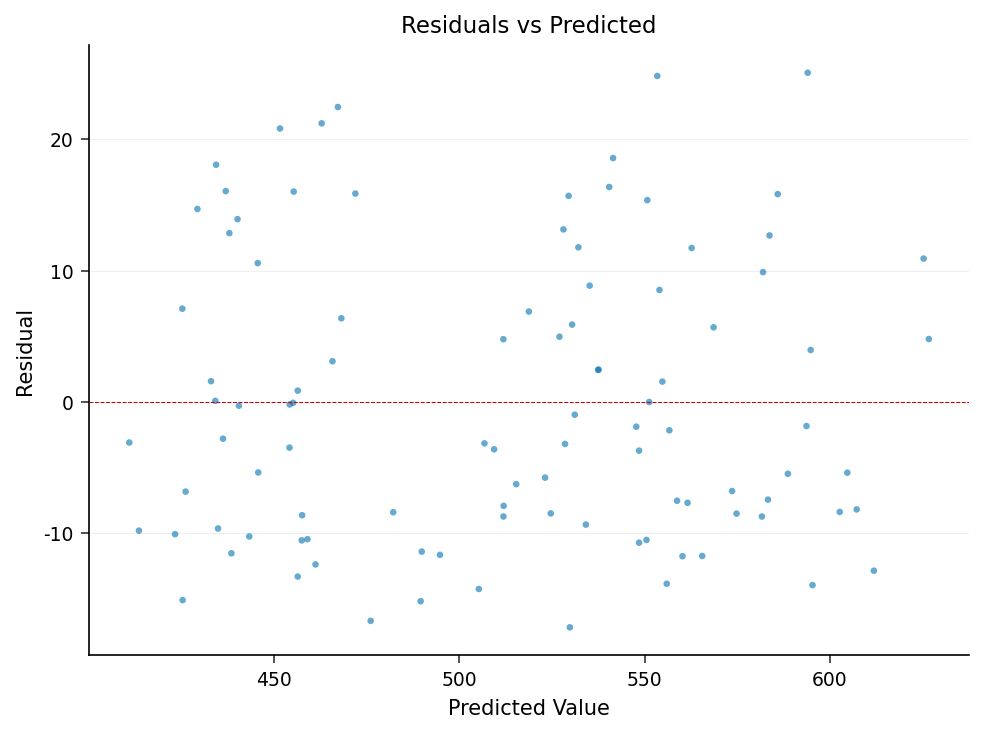

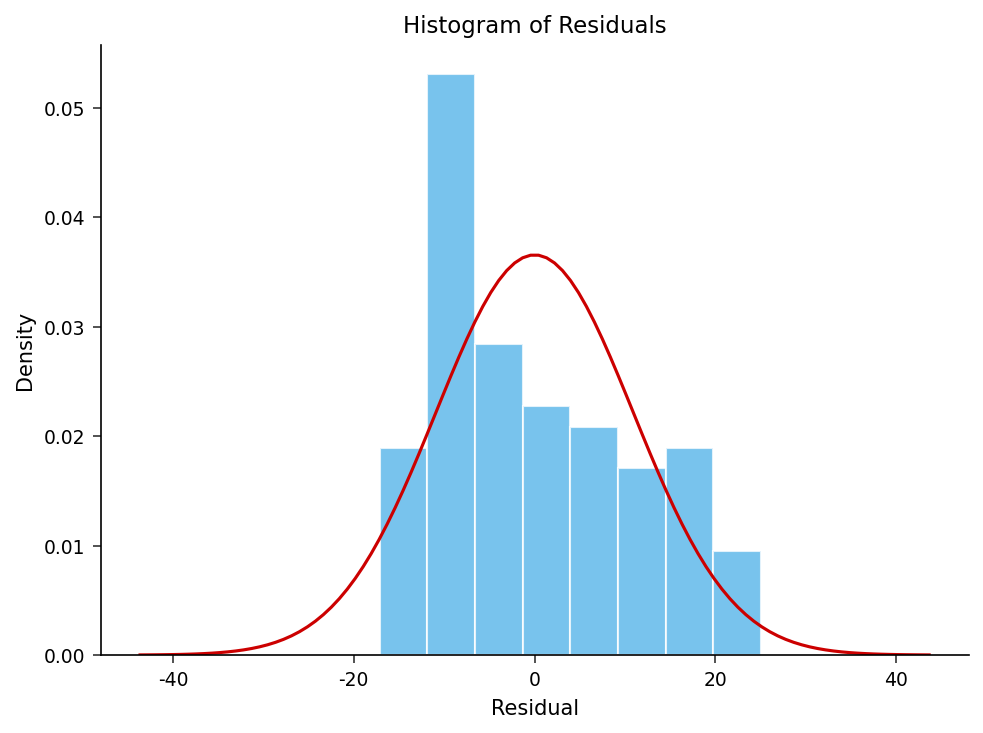

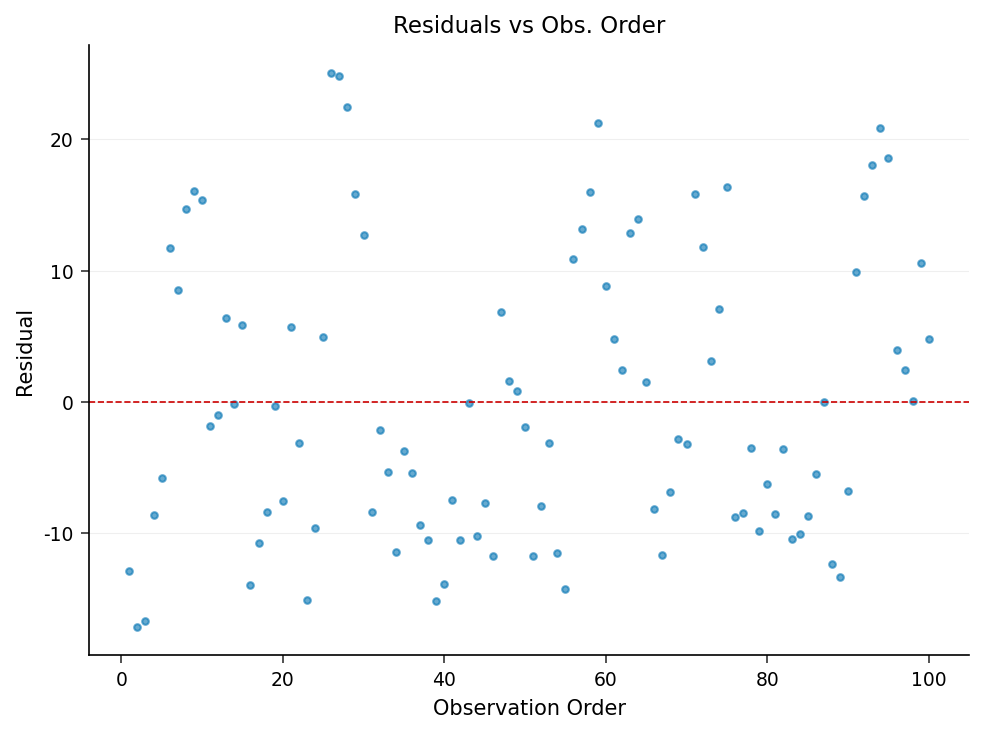

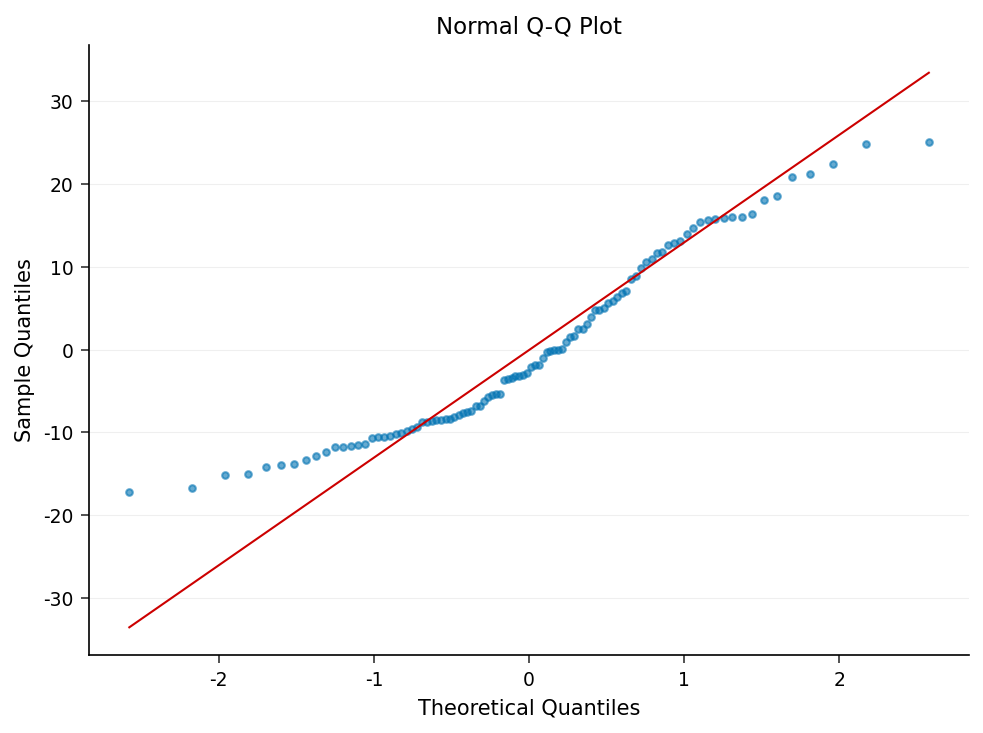

In [3]:
PROCEDURE hplmixed GEGEVENS=meter;
   KLASSE sub plan hh_id;
   MODEL kwh = hdd plan / SOLUTION cl ddfm=residual;
   RANDOM INTERCEPT / SUBJECT=sub;
   RANDOM INTERCEPT / SUBJECT=hh_id;
   id hh_id sub month;
   label kwh="Verbruik (kWh)" hdd="Stookgraaddagen" plan="Tariefplan" hh_id="Huishouden-ID" sub="Onderstation-ID" month="Maand";
   UITVOER out=fitted pred=pred_kwh resid=resid_kwh;
UITVOEREN;

## Stap 4 — Inspecteer de gefitte waarden en residuen

De dataset `fitted` bevat één rij per metermeting met de modelvoorspelling (`Pred`) en het residu (`Resid`). Door de eerste rijen te tonen kunnen we visueel beoordelen hoe nauwkeurig het model het waargenomen verbruik voor één huishouden over opeenvolgende maanden volgt.

In [4]:
PROCEDURE AFDRUKKEN GEGEVENS=fitted(obs=10) noobs;
   VARIABELE hh_id sub month plan hdd kwh Pred Resid;
   label hh_id="Huishouden-ID" sub="Onderstation-ID" month="Maand" plan="Tariefplan" hdd="Stookgraaddagen" kwh="Verbruik (kWh)" Pred="Voorspelling" Resid="Residu";
   TITEL "Voorspellingen en residuen (eerste huishoudens)";
UITVOEREN;
TITEL;

                                    Voorspellingen en residuen (eerste huishoudens)                                     

Huishouden-ID  Onderstation-ID  Maand  Tariefplan  Stookgraaddagen  Verbruik (kWh)
            1                1      1  FLAT          28.8380614878  599.0504286147
            1                1      2  FLAT          18.7392575072  512.7075775233
            1                1      3  FLAT          12.1220317614  459.4435078267
            1                1      4  FLAT           9.8454225534  448.9841287871
            1                1      5  FLAT          17.9167016733  517.4130075929
            2                1      1  TOU           25.7201183383  574.4250151622
            2                1      2  TOU           24.6513737779  562.5507448183
            2                1      3  TOU            9.3016021043  444.0164942678
            2                1      4  TOU           10.2428175968  453.0216521526
            2                1      5  TOU      


NOTE: PROC PRINT data=fitted

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Stap 5 — Herfit met Maximum Likelihood voor modelvergelijking

De standaard schattingsmethode is REML, wat geschikt is voor het rapporteren van variantiecomponenten. Wanneer je modellen wilt vergelijken die verschillen in hun *vaste* effecten via op likelihood gebaseerde criteria, is ML de juiste methode. We herfitten met `method=ml` en onderdrukken de klasseniveau-lijst met `noclprint` om de output compact te houden.


                       The HPLMIXED Procedure
                  Data Set: meter
                  Estimation Method: Maximum Likelihood (ML)
                  NOCLPRINT: class-level table suppressed


      The Mixed Procedure       
       Model Information        

Item                       Value
----------------------  --------
Dependent Variable           kwh
Estimation Method             ML
Number of Observations       100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  SUB         1.3158
Intercept  HH_ID     105.0408
Group                  0.0000
Residual             118.9957

        Type III Tests of Fixed Effects         

Effect      Num DF    Den DF   F Value    Pr > F
--------  --------  --------  --------  --------
hdd              1      94.0   2783.47    <.0001
plan             1      88.5    120.59    <.0001

         Fit Statistics          

Statistic                   Value
-----------------------  --------
-2


NOTE: PROC MIXED data=meter

NOTE: PROC MIXED: using Python wrapper (mixed_renderer.py).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: Formula: kwh ~ hdd + C(plan)
NOTE: Group variable: sub
NOTE: Estimation method: ML (reml=False)
NOTE: 
NOTE: Mixed Linear Model Results:
NOTE:             Mixed Linear Model Regression Results
NOTE: ==============================================================
NOTE: Model:               MixedLM   Dependent Variable:   kwh      
NOTE: No. Observations:    100       Method:               ML       
NOTE: No. Groups:          5         Scale:                118.9957 
NOTE: Min. group size:     20        Log-Likelihood:       -380.8482
NOTE: Max. group size:     20        Converged:            Yes      
NOTE: Mean group size:     20.0                                     
NOTE: --------------------------------------------------------------
NOTE:                  Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
NOTE: ----------

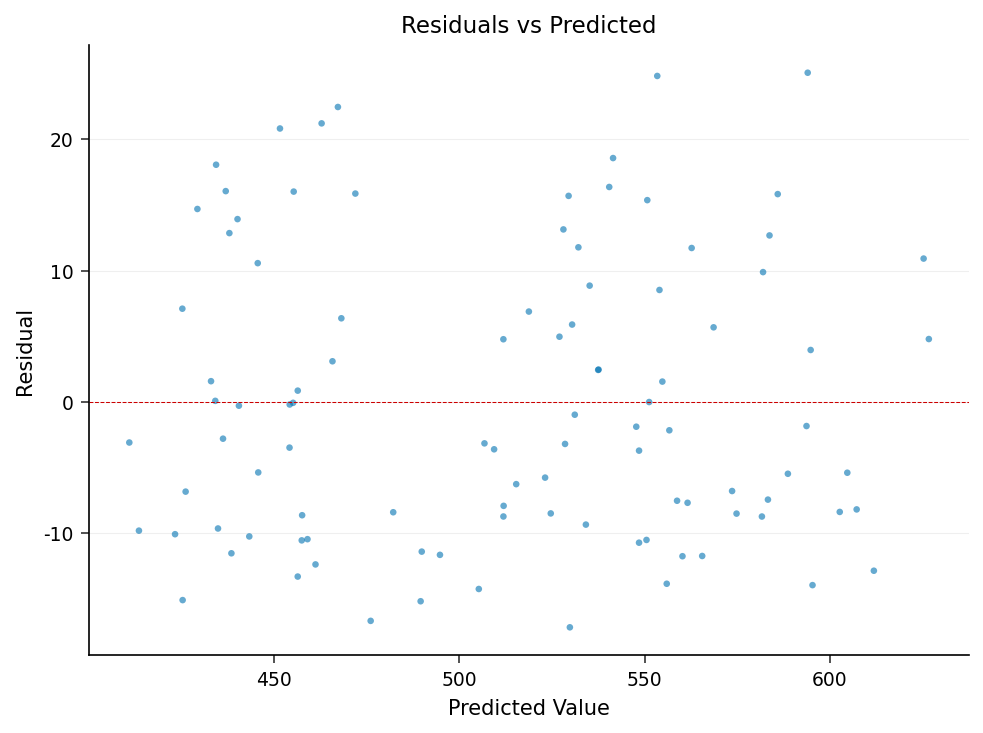

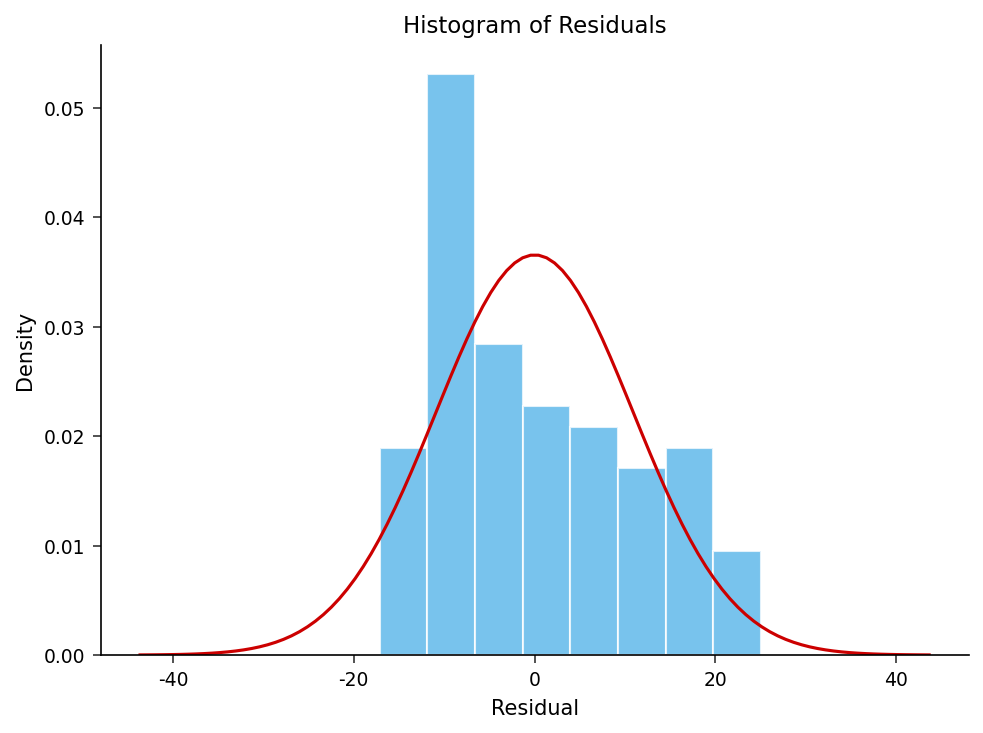

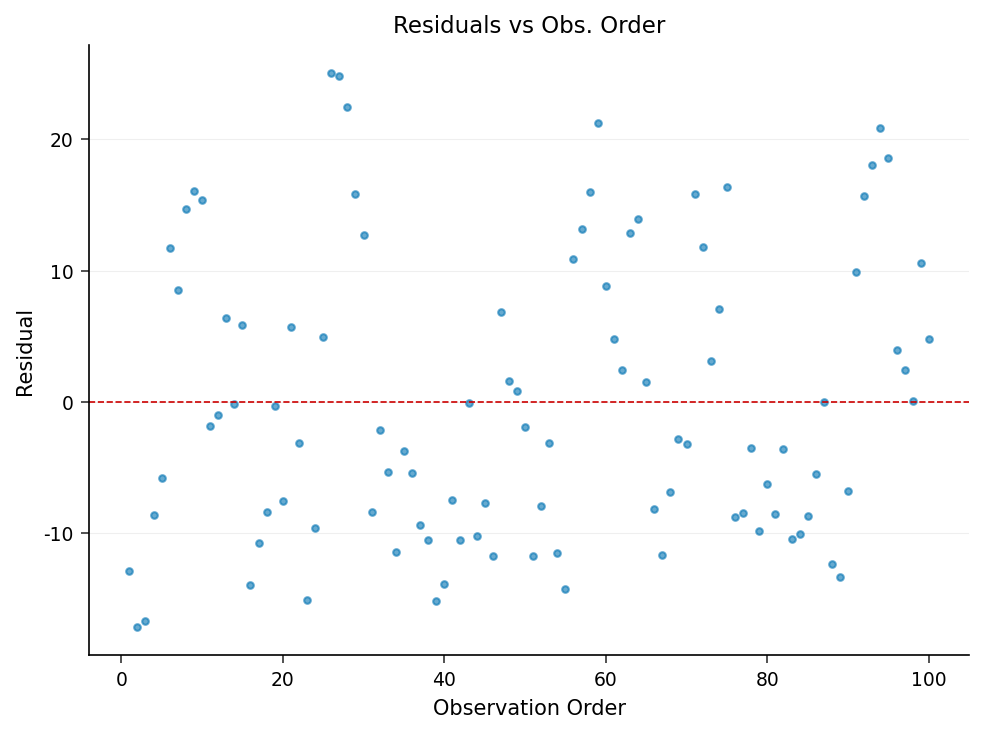

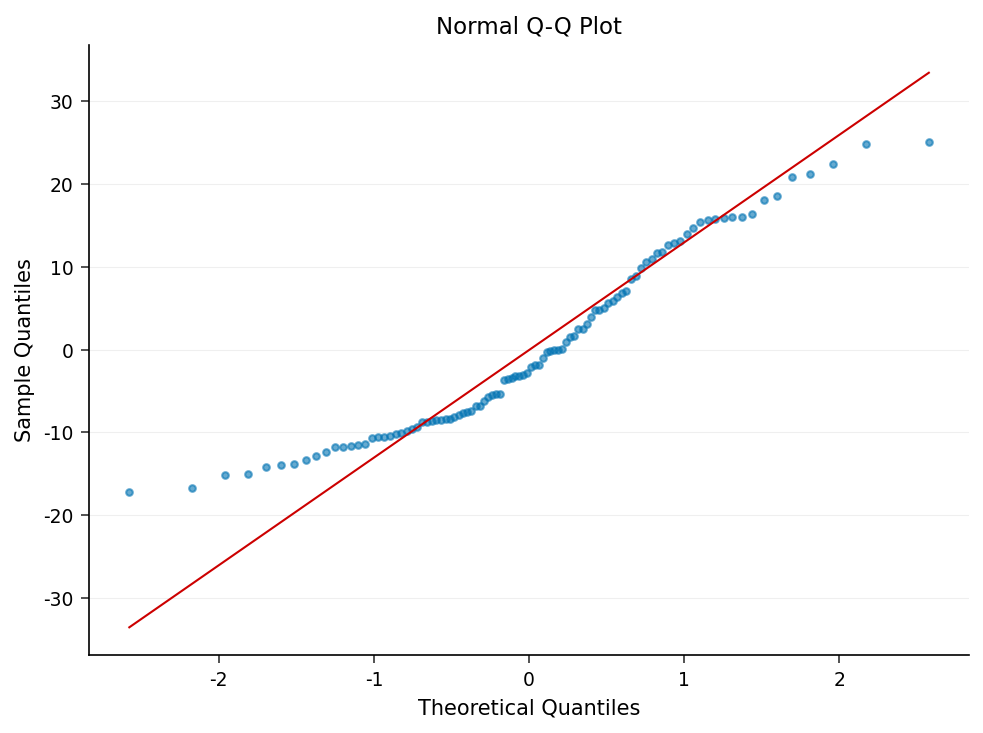

In [5]:
PROCEDURE hplmixed GEGEVENS=meter METHOD=ml noclprint;
   KLASSE sub plan hh_id;
   MODEL kwh = hdd plan / SOLUTION;
   RANDOM INTERCEPT / SUBJECT=sub;
   RANDOM INTERCEPT / SUBJECT=hh_id;
   label kwh="Verbruik (kWh)" hdd="Stookgraaddagen" plan="Tariefplan";
UITVOEREN;

## Interpretatie van de resultaten

**Vaste effecten.** De tabel `Solution for Fixed Effects` toont een grote, zeer significante helling op `hdd` van **8,12 kWh** extra maandelijks verbruik per stookgraaddag (t = 51,96, p < .0001) — wat bevestigt dat het weer de dominante drijver van de vraag is. Ook de term `plan` is significant: huishoudens met een piek-/dalplan verbruiken **11,9 kWh** minder dan huishoudens met een vast tarief (t = −10,84, p < .0001), wat de vraagsturende waarde van het tarief kwantificeert. De optie `cl` begrenst elke schatting (bijv. de helling van `hdd` valt binnen ongeveer 7,82–8,43), en de `Type III Tests of Fixed Effects` bevestigen dat beide predictoren ertoe doen (`hdd` F = 2700,19, `plan` F = 117,53, beide p < .0001).

**Variantieontbinding.** De tabel `Covariance Parameter Estimates` splitst de onverklaarde variatie op in een onderstationcomponent (**1,32**), een veel grotere huishoudencomponent (**105,04**), en residuele maand-op-maand ruis (**122,68**). De aanzienlijke huishoudenvariantie is het signaal waar een nutsbedrijf om geeft: blijvende verschillen in basislast op woningniveau die niet worden verklaard door weer of tarief — de doelgroep voor energie-efficiëntie- of vraagsturingsprogramma's. De bijna-nul onderstationcomponent zegt dat, na correctie voor huishoudens, verschuivingen op voedingslijnniveau weinig toevoegen op dit panel.

**Fit en voorspellingen.** De fitstatistieken (−2 Res Log Likelihood 758,15, AIC 766,15, BIC 776,57 onder REML) bieden een basislijn voor het vergelijken van alternatieve specificaties, en de `OUTPUT`-dataset levert per-meting voorspellingen en residuen (de kolommen `Pred` en `Resid`) voor belastingsvoorspellingsdiagnostiek of anomaliedetectie. Herfitten met `method=ml` verandert de likelihood-basis die wordt gebruikt om concurrerende structuren van vaste effecten te vergelijken (AIC 771,70, BIC 784,72), terwijl de schattingen van de vaste effecten in wezen ongewijzigd blijven.

Voor productiegebruik schaalt hetzelfde model — via de threading- en gedistribueerde opties van het `PERFORMANCE`-statement — van deze demonstratie met 100 metingen naar de miljoenen metingen die een echte advanced-metering-infrastructure-implementatie genereert.